# Clustering of names

This notebook examines the challenge of inconsistencies in applicant names within PATSTAT data, a critical issue for accurately retrieving patent applications by the same entity.

## Prerrequisites

This notebook has been written for an audience already familiar with TIP. For users completely new to the platform, we recommend to follow the [TIP basic course](https://e-courses.epo.org/enrol/index.php?id=416) before reading this analysis.

## Disclaimer

This notebook is published as a showcase of the capabilities of TIP as a data processing environment. It is not intended to derive any statistical conclusion other than the presentation of the retrieved data. The EPO is not expressing any opinion extrapolated from the analysis.

## Introduction to the problem

In PATSTAT, it is possible to retrive, for each application, the corresponding applicants and its address. These two attributes are reported exactly as they appear in the filing at the receiving office. Therefore, it goes without saying that, for the same applicant, we can have the name written in different ways, and the same for the address. There are several cases: the order of the words is different, sometimes uppercase is preferred over lowercase, accents could be removed or not, in some cases the legal forms (e.g. No Limited Comany, Sociedad de Responsabilidad Limitada, Genossenschaft, etc.) are present (abbreviated or not), there may be some typos, some numbers in the address could be omitted, and so on. If our intention is to retrieve all the applications filed by a specific company and we write a query filtering by asking only applications with `person_name` equal to the name of the company of interest, we are actually filtering by a specific form of that name, i.e. one of its variations over many possibilities. This would result in a limited search. Indeed, for the computer the mispellings and whatsoever are just different strings, and so interpreted as different names. This issue raises the need of an algorithm able to cluster the names corresponding to the same applicant. 

There are already efforts in this direction in PATSTAT. Attribute `psn_name` stands for **PATSTAT Standardised Name**. Here we can find applicants names resulting from the standardisation provided by the University of Leuven. Attribute `han_name` stands for **Harmonised Applicant Name** and refers to the harmonisation provided by the **OECD**, where the applicants names are matched to company names listed in the ORBIS database. Both of the harmonisations address the points aforementioned using different approaches.

Of course, the idea of having an algorithm developed internally is appealing, in particular after that the collaboration with the University of Leuven has been interrupted. In this notebook, the user is given with basic ideas and examples on how to clean the names to spot different names that actually refer to the same applicant. Moreover, a cross-check with the addresses is performed: if both company names and addresses match after cleaning, then the two names are grouped together in the same cluster. The obtained results are then measured by assessing the degree of reduction in the size of the dataset after running the code. Also, the results are compared with the outcome reached by PSN and HAN methods.

We start by importing the necessary libraries and tables, other than initialising the PATSTAT client. 

In [1]:
from epo.tipdata.patstat import PatstatClient
from epo.tipdata.patstat.database.models import TLS206_PERSON, TLS207_PERS_APPLN, TLS201_APPLN
import pandas as pd
import numpy as np
import re
from collections import defaultdict
import unicodedata
from sqlalchemy import func

# Initialise the PATSTAT client
patstat = PatstatClient(env='PROD')

# Access ORM
db = patstat.orm()

The attributes `person_name` and `person_address` are found in table TLS206 but we also need table TLS207 and TLS201 to perform the join via the `appln_id` attribute and apply some filters, such as `appln_auth` equal to 'EP' and ignoring applications with `applt_seq_nr` equal to 0, i.e. persons that are not applicants, and `person_name` that are empty.

In [21]:
q = db.query(
    TLS206_PERSON.person_name,
    TLS206_PERSON.person_address
).filter(
    TLS201_APPLN.appln_auth == 'EP', # only applications filed to EPO 
    TLS206_PERSON.person_name != None,
    TLS206_PERSON.person_name != '',
    TLS207_PERS_APPLN.applt_seq_nr != 0  # we want applicants only
).distinct(
    TLS206_PERSON.person_name,
    TLS206_PERSON.person_address
).join(
    TLS207_PERS_APPLN, TLS206_PERSON.person_id == TLS207_PERS_APPLN.person_id,
).join(
    TLS201_APPLN, TLS207_PERS_APPLN.appln_id == TLS201_APPLN.appln_id
)

raw = patstat.df(q)

raw

,person_name,person_address
0,Curacyte AG,"Gollierstrasse 70,80339 München"
1,"Al Amri, Moosa Eisa","Al Reem Tower, Maktoum Street,Suite 302-303, P..."
2,Ishida Europe Limited,"11 Kettles Wood Drive,Woodgate Business Park,B..."
3,Conti Temic microelectronic GmbH,"Sieboldstrasse 19,90411 Nürnberg"
4,STMicroelectronics Limited,"1000 Aztec West,Almondsbury, Bristol, BS32 4SQ"
...,...,...
846199,Chemia S.p.A.,"Via Statale, 327,Frazione Dosso,44047 Sant'Ago..."
846200,Plamet Limited Liability Company,"Capitol Avenue 1912,Cheyenne, Wyoming 82001"
846201,"JIMRO CO., LTD.","351-1 Nishiyokote-machi,Takasaki-shi,Gumma 370..."
846202,Tomtom Places Development B.V.,"Oosterdokstraat 114,1011DK Amsterdam"


## Defining functions

### Removing of accents

The first point that we address is the handling of accents. Some names instances may keep the accents and other my not. Therefore, we decide to substitute the letter with the accent with the same letter without the accent every time we find one. We use the `unicodedata` library to carry out this operation.

In [3]:
def remove_accents(text):
    # Normalize the text to decompose characters with accents
    normalized_text = unicodedata.normalize('NFD', text)
    # Filter out diacritical marks (accents)
    unaccented_text = ''.join(char for char in normalized_text if unicodedata.category(char) != 'Mn')
    return unaccented_text

### Cleaning of names

In this function, we remove punctuation and non-alphanumeric characters. Then we convert every token that constitutes the names in upper case, we apply the `remove_accents` function to every token, and finally we ignore legal forms. To perform this last step, we check if the token (after the first cleaning steps) is in the [list of legal forms and abbreviations](https://www.gleif.org/en/about-lei/code-lists/iso-20275-entity-legal-forms-code-list?utm_source=chatgpt.com) provided by the Global Legal Entity Identifier Foundation (GLEIF). The elements of this list are subject to a similar cleaning before comparison, as we will see later on in this notebook. The very last step is the alphabetic sorting of the tokens to ignore differences due to ordering. At this point, the tokens are ready to be collected together as a cleaned name.

In [4]:
# Function to normalize a name
def normalize_name(name, legal_forms):
    # Split the name into words (tokens)
    tokens = re.findall(r'\b\w+\b', name)
    
    # Normalize tokens: lowercase and replace abbreviations
    normalized_tokens = []
    for token in tokens:
        # Convert to lowercase
        token = token.upper()
        # Remove accents
        token = remove_accents(token)
        # Remove legal forms if found
        if token not in legal_forms:
            normalized_tokens.append(token)
    
    # Sort the tokens to ignore word order
    sorted_tokens = sorted(normalized_tokens)
    
    # Join tokens into a single string for standardized comparison
    return ' '.join(sorted_tokens)

### Cleaning of addresses

The cleaning function for addresses follows a similar procedure. In this case, there is not any comprehensive list prefexis and abbreviations concerning addresses. This is why we defined a dictionary of typical prefexis and their corresponding abbreviations. Obviously this list does not consider analogous words in other languages than English but it is a good starting point. Thus, when one of the prefexis is found, it is replaced with its abbreviation.

One particular case for addresses is the Japanese addresses system. In the function we take into account this specificity. It is important to highlight that this approach is too deep into the individual case, while of course we must expect significant differences in the addresses systems of some other countries. Nonetheless, this is a good opportunity to show how we can handle "pathological cases". In Japan, addresses contain two sequences of numbers. If the address is written in English, the first sequence to appear is the one relative to the area of the city, the building, and in some cases the floor: for example 5-5 or 5-5-4. The second sequence represents the postal code. When the address in written in Japanese, the two sequences appear in reversed order. To keep it simple, here we address only the first case. By the way, why is this a problem? Having such long sequences of numbers, possibly different, corresponding to the same street (or square, avenue or whatever) paves the path to an undesired split. Indeed, big settlement companies that consist of many buildings, with so different numbers in the sequences found in the address, would be assigned to different clusters, even if the company (so the applicant) is the same.

One simple solution to fix this "excess of information" is to disregard some of these numbers. In practice, every time that we find a number in the address (so the token at hand is an integer) we check if it is the first number encountered. We add the number to the sequence of normalised tokens only if the counting is less than 2 (this hyperparameter can be changed accordingly to which extent we want to disregard the numbers). How do we recognise a number? We can use a `try-except` construct. Briefly, the algorithm tries to convert the current token to an integer and if it is possible the counter is increased by 1. If this is not possible, instead of launching a message error, the algorithm just jumps to the next step. This is done by inserting the `pass` command in the 'except' clause.

In [12]:
# Function to normalize an address
def normalize_address(address):
    abbreviations = {"ST": "STREET",
        "AVE": "AVENUE",
        "RD": "ROAD",
        "BLVD": "BOULEVARD",
        "DR": "DRIVE",
        "LN": "LANE",
        "CT": "COURT",
        "PL": "PLACE",
        "TER": "TERRACE",
        "PKWY": "PARKAWAY",
        }
    
    # Split the name into words (tokens)
    tokens = re.findall(r'\b\w+\b', address)
    
    # Normalize tokens: lowercase and replace abbreviations
    normalized_tokens = []
    numbers = 0
    for token in tokens:
        # try-except construct to spot integers among the tokens: if the token is an integer then 'numbers' is increased by 1, otherwise the algorithm jumps over
        try:
            int_token = int(token)  # attempt to convert the token to an integer to know if it is a number
            if numbers < 2:
                normalized_tokens.append(token)
            numbers += 1
            continue
        except:
            pass
        # Convert to lowercase
        token = token.upper()
        # Remove accents
        token = remove_accents(token)
        # Replace abbreviation if found
        token = abbreviations.get(token, token)
        normalized_tokens.append(token)
    
    # Sort the tokens to ignore word order
    sorted_tokens = sorted(normalized_tokens)
    
    # Join tokens into a single string for standardized comparison
    return ' '.join(sorted_tokens)

## Cleaning of the legal forms

The legal forms are subject to the same cleaning as for the name, so that we can search for matches afterwards. The list of legal forms in different languages and their corresponding abbreviations is the one aforementioned, found at the [GLEIF website](https://www.gleif.org/en/about-lei/code-lists/iso-20275-entity-legal-forms-code-list?utm_source=chatgpt.com) and downloaded in CSV format. The file is in this repository and readable by simply running the cell code below. The user is kindly invited to take a look to the file to get an idea of its structure. The only columns that we need are 'Entity Legal Form name Local name', where we find the legal forms in the different languages, and 'Abbreviations Local language', containing the corresponding (possibly multiple) abbreviations.

When multiple abbreviations are present, these are separated by a ';', hence this is the criteria for the splitting. The avvreviations may contain dots or not. Therefore, first we search for punctuation other than ';' and we remove it if any. Only then, we can put the token in uppercase and then remove possible accents.

In [6]:
# Read the CSV file and convert it in a dataframe
code_list = pd.read_csv("2023-09-28-elf-code-list-v1.5.csv")
# Take the column containing the legal form in the different languages and convert it into a list
legal_forms = list(code_list['Entity Legal Form name Local name'].values)
# Same with the corresponding abbreviations
abbr = list(code_list['Abbreviations Local language'].values)
abbrs = []
for a in abbr:
    # Ignore empty cells
    if not pd.isna(a):
        # Create a new token every time a ';' is encountered, since this character is used to separate alternative
        tk = a.split(";")
        # Check if the token is not a single character
        if type(tk) == list:
            for k in tk:
                # Check if the token contains punctuation other than ';'
                if re.search(r'[^\w\s]', k):
                    # Remove the punctuation
                    k = re.findall(r'\b\w+\b', k)
                    join = ''.join(k)
                    abbrs.append(join)
                # Otherwise we just convert it to uppercase and remove the accents, then join to the list of abbreviations
                else:
                    k = k.upper()
                    k = remove_accents(k)
                    abbrs.append(k)
        # Otherwise we just convert it to uppercase and remove the accents, then join to the list of abbreviations
        else:
            tk = tk.upper()
            tk = remove_accents(tk)
            abbrs.append(tk)


## Cleaning of names and addresses and grouping

At this point we have all the tools to perform the clustering cross-checking names and addresses. We create a dictionary of dictionaries: the external dictionary has the rows indices of the dataframe as keys, the internal dictionaries have two keys, i.e. `person_name` and `person_address`, and the corresponding values in the dataframe as attributes. Then we iterate over the pairs *index - dictionaries*, and we retrive name and address from the second, to which we apply the functions `normalize_name` and `normalize_address` respectively. We combine the two to create a key and then we append the index to this key (a new key is created if not existing yet).

In [22]:
# Initialize a dictionary to hold clusters
clusters = defaultdict(list)

# Transform cleaned names into a dictionary
names_dict = {
    idx: {"person_name": row.person_name, "person_address": row.person_address}
    for idx, row in raw.iterrows()
}

# Process each name in names_dict
for idx, data in names_dict.items():
    name = data['person_name']
    address = data['person_address']
    # Normalize the name 
    cleaned_name = normalize_name(name, abbrs)
    # Normalize the address
    cleaned_address = normalize_address(address)
    # Create a key combining cleaned_name and cleaned_address
    key = str(cleaned_name)+" - "+str(cleaned_address)
    # Add the index to the cluster corresponding to this key
    clusters[key].append(idx)
    

In the following, we display the 10 biggest clusters, showing the key, i.e. the cleaned names and addresses, and all the instances found.

In [23]:
# Compute the sizes of the clusters
cluster_sizes = {key: len(indices) for key, indices in clusters.items()}

# Sort the clusters by size in descending order
sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)

# Now, let's print out the top clusters with the most names
top_n = 10  # Change this number to see more or fewer clusters
print(f"Top {top_n} clusters with the most names:")
for i in range(top_n):
    key, size = sorted_clusters[i]
    print(f"\nCluster Key: '{key}' with {size} names:")
    for idx in clusters[key]:
        print(f"Index: {idx}, Name: {names_dict[idx]['person_name']}, Address: {names_dict[idx]['person_address']}")


Top 10 clusters with the most names:

Cluster Key: 'HONDA MOTOR - 1 1 AOYAMA CHOME KU MINAMI MINATO TOKYO' with 33 names:
Index: 57034, Name: Honda Motor Co., Ltd., Address: 1-1, Minami-Aoyama, 2-chome,Minato-ku,Tokyo 107-8556
Index: 85334, Name: Honda Motor Co., Ltd., Address: 1-1, Minami Aoyama 2-chome,Minato-ku,Tokyo 107-8556
Index: 174714, Name: Honda Motor Co., Ltd., Address: 1-1, Minami-Aoyama 2-chome,Minato-ku,Tokyo 1078556
Index: 182892, Name: HONDA MOTOR CO., LTD., Address: 1-1 Minami-Aoyama 2-chome,Minato-ku,Tokyo 107-8556
Index: 192895, Name: HONDA MOTOR COMPANY LTD., Address: 1-1, Minami Aoyama 2-chome,Minato-ku,Tokyo 107-0062
Index: 263099, Name: HONDA MOTOR CO., LTD., Address: 1-1, Minami-Aoyama 2-chome,Minato-ku,Tokyo, 107-8556
Index: 297269, Name: HONDA MOTOR CO., LTD., Address: 1-1, Minami-Aoyama 2-chome, Minato-ku,Tokyo 107-8556
Index: 331433, Name: Honda Motor Co., Ltd., Address: 1-1, Minami-Aoyama, 2-chome Minato-ku,Tokyo 107-8556
Index: 331717, Name: HONDA MOTOR CO

Take a look at the biggest cluster, at the top of the list displayed above, with key 'HONDA MOTOR - 1 1 AOYAMA CHOME KU MINAMI MINATO TOKYO'. The name and the address name are the same in all the instances. In the same way, all the addresses start with 1-1. Only the last numbers change in some cases. This may suggest that we are in front of the same company, located in the same area, just so big that it comprises multiple buildings.

One other example that shows the intricacy of this task is key 'ELECTRONICS'. It appears twice in the name side of our top 10 list. If we look at the addresses, they are very similar, and the city is the same. This may suggest that the two addresses differ only becuase of a mispelling error or a different transliteration. Also, looking at the name instances, we realise that the company at hand is the well-known LG Electronics. However, LG is also the abbreviation of the German legal form Landwirtschaftliche Gesellschaft, hence it has been removed. Avoiding overlapping situations is far from trivial.

## Reduction factor

After running the algorithm, it is interesting to evaluate its performance. One indicator to assess the quality of the algorithm is the reduction factor, i.e. the percentage of reduction in the size of the dataset after applying the clustering.

In [24]:
# Total number of clusters
num_clusters = len(clusters)
# Total number of rows in the initial dataframe
original_len = len(raw)
# Compute the reduction factor
reduction_factor = 1 - (num_clusters / original_len)
# Print the reduction factor at the fourth decimal
print(f"The reduction factor that has been reached is of {reduction_factor:.4f}.")

The reduction factor that has been reached is of 0.0701.


Let's see what is the change in raw numbers.

In [25]:
print(f"We started with {original_len} names in total.")
# Total number of clusters
print(f"After cleaning, there are {len(clusters)} clusters in total.")

We started with 846204 names in total.
After cleaning, there are 786886 clusters in total.


## Comparison with PSN and HAN harmonizations

In [17]:
psn_names = db.query(
    TLS206_PERSON.psn_name
).filter(
    TLS201_APPLN.appln_auth == 'EP', # only applications filed to EPO 
    TLS206_PERSON.person_name != None,
    TLS207_PERS_APPLN.applt_seq_nr != 0
).distinct(
    TLS206_PERSON.psn_name
).join(
    TLS207_PERS_APPLN, TLS206_PERSON.person_id == TLS207_PERS_APPLN.person_id,
).join(
    TLS201_APPLN, TLS207_PERS_APPLN.appln_id == TLS201_APPLN.appln_id
)

han_names = db.query(
    TLS206_PERSON.han_name
).filter(
    TLS201_APPLN.appln_auth == 'EP', # only applications filed to EPO 
    TLS206_PERSON.person_name != None,
    TLS207_PERS_APPLN.applt_seq_nr != 0
).distinct(
    TLS206_PERSON.han_name
).join(
    TLS207_PERS_APPLN, TLS206_PERSON.person_id == TLS207_PERS_APPLN.person_id,
).join(
    TLS201_APPLN, TLS207_PERS_APPLN.appln_id == TLS201_APPLN.appln_id
)

psn_df = patstat.df(psn_names)
han_df = patstat.df(han_names)
psn = len(psn_df)
han = len(han_df)

# reduction factors
psn_reduction_factor = 1 - psn / original_len 
han_reduction_factor = 1 - han / original_len 

print(f"There are {psn} names resulting from PSN harmonization. The reduction factor is equal to {psn_reduction_factor}.")
print(f"There are {han} names resulting from HAN harmonization. The reduction factor is equal to {han_reduction_factor}.")

There are 592068 names resulting from PSN harmonization. The reduction factor is equal to 0.30032557122683035.
There are 591451 names resulting from HAN harmonization. The reduction factor is equal to 0.3010547089653216.


As expected, our showcase implementation leads to a smaller reduction. The reduction factor reached by our code is approximately 7%, while the two harmonizations attain a reduction factor around 30% of the original dataset. We can better visulise the proportion with a bar plot.

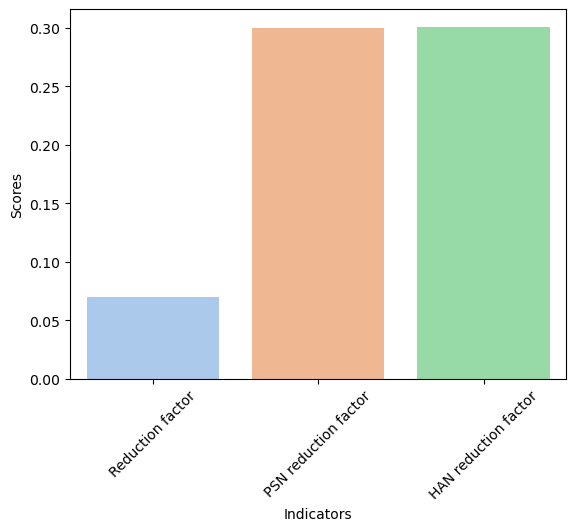

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

reduction_factors = pd.DataFrame({'Indicators': ['Reduction factor', 'PSN reduction factor', 'HAN reduction factor'], 'Scores': [reduction_factor, psn_reduction_factor, han_reduction_factor]})

# Create bar plot
sns.barplot(x='Indicators', y='Scores', data=reduction_factors, hue='Indicators', palette='pastel', legend=False)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show plot
plt.show()

We do the same for the total numbers resulting from the application of the three methods.

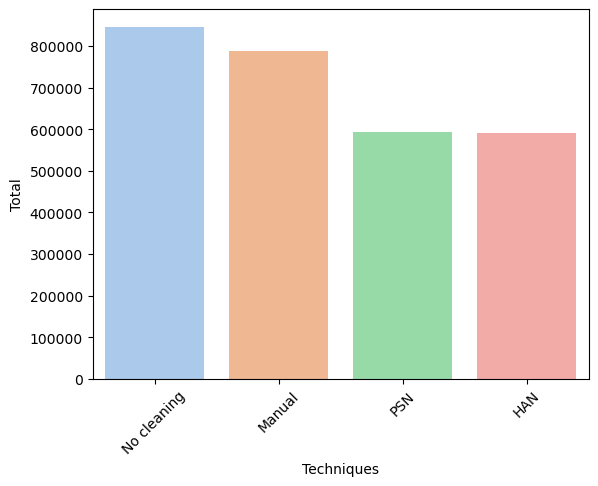

In [27]:
total_numbers = pd.DataFrame({'Techniques': ['No cleaning', 'Manual', 'PSN', 'HAN'], 'Total': [original_len, num_clusters, psn, han]})

# Create bar plot
sns.barplot(x='Techniques', y='Total', data=total_numbers, hue='Techniques', palette='pastel', legend=False)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show plot
plt.show()

One other aspect that can reveal if we are moving in the right direction is which companies owns the highest number of applications according to PSN and HAN harmonisations, compared to our clustering. Therefore, we retrieve the lists of PSN names and HAN names and count the number of occurrences grouped by names, and we order by the number of occurrences in descending order.

In [5]:
top_psn = db.query(
    TLS206_PERSON.psn_name,
    func.count(TLS206_PERSON.person_name).label('Number of instances')
).filter(
    TLS201_APPLN.appln_auth == 'EP', # only applications filed to EPO 
    TLS206_PERSON.person_name != None,
    TLS207_PERS_APPLN.applt_seq_nr != 0
).join(
    TLS207_PERS_APPLN, TLS206_PERSON.person_id == TLS207_PERS_APPLN.person_id,
).join(
    TLS201_APPLN, TLS207_PERS_APPLN.appln_id == TLS201_APPLN.appln_id
).group_by(
    TLS206_PERSON.psn_name
).order_by(
    func.count(TLS206_PERSON.person_name).desc()
).limit(5)

top_psn_df = patstat.df(top_psn)
top_psn_df

,psn_name,Number of instances
0,SIEMENS,49207
1,PHILIPS ELECTRONICS,45499
2,SAMSUNG ELECTRONICS COMPANY,41484
3,HUAWEI TECHNOLOGIES COMPANY,34567
4,ROBERT BOSCH,33449


In [6]:
top_han = db.query(
    TLS206_PERSON.han_name,
    func.count(TLS206_PERSON.person_name).label('Number of instances')
).filter(
    TLS201_APPLN.appln_auth == 'EP', # only applications filed to EPO 
    TLS206_PERSON.person_name != None,
    TLS207_PERS_APPLN.applt_seq_nr != 0
).join(
    TLS207_PERS_APPLN, TLS206_PERSON.person_id == TLS207_PERS_APPLN.person_id,
).join(
    TLS201_APPLN, TLS207_PERS_APPLN.appln_id == TLS201_APPLN.appln_id
).group_by(
    TLS206_PERSON.han_name
).order_by(
    func.count(TLS206_PERSON.person_name).desc()
).limit(5)

top_han_df = patstat.df(top_han)
top_han_df

,han_name,Number of instances
0,SIEMENS AG,48339
1,SAMSUNG ELECT CO LTD,47743
2,KON PHILIPS ELECT NV,36776
3,HUAWEI TECH CO LTD,34920
4,ROBERT BOSCH GMBH,33155


We can see that, even if with a small differnce in the ranking, the top 5 names are the same for the two harmonisation techniques. However, our clustering does not match this ranking.

## Disregarding the address

Since the address is also source of complications, let's try to clustering the names without considering the addresses. 

In [28]:
# Initialize a dictionary to hold clusters
bigger_clusters = defaultdict(list)

# Process each name in names_dict
for idx, data in names_dict.items():
    name = data['person_name']
    address = data['person_address']
    # Normalize the name 
    cleaned_name = normalize_name(name, abbrs)
    # Create a key combining cleaned_name and cleaned_address
    key = str(cleaned_name)
    # Add the index to the cluster corresponding to this key
    bigger_clusters[key].append(idx)
    

Now we display the top 10 names (but not the instances in the database).

In [29]:
# Compute the sizes of the clusters
cluster_sizes = {key: len(indices) for key, indices in bigger_clusters.items()}

# Sort the clusters by size in descending order
sorted_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)

# Now, let's print out the top clusters with the most names
top_n = 10  # Change this number to see more or fewer clusters
print(f"Top {top_n} clusters with the most names:")
for i in range(top_n):
    key, size = sorted_clusters[i]
    print(f"\nCluster Key: '{key}' with {size} names:")
    '''
    for idx in bigger_clusters[key]:
        print(f"Index: {idx}, Name: {names_dict[idx]['person_name']}, Address: {names_dict[idx]['person_address']}")
    '''


Top 10 clusters with the most names:

Cluster Key: 'ELECTRONICS' with 323 names:

Cluster Key: '' with 273 names:

Cluster Key: 'ELECTRONICS SAMSUNG' with 267 names:

Cluster Key: 'CALIFORNIA OF OF REGENTS THE THE UNIVERSITY' with 172 names:

Cluster Key: 'ELECTRIC INDUSTRIAL MATSUSHITA' with 139 names:

Cluster Key: 'HONEYWELL INTERNATIONAL' with 130 names:

Cluster Key: 'ABBOTT LABORATORIES' with 122 names:

Cluster Key: 'DEVELOPMENT HEBREW JERUSALEM OF OF RESEARCH THE UNIVERSITY YISSUM' with 121 names:

Cluster Key: 'ELECTRIC SANYO' with 117 names:

Cluster Key: 'AMERICA AND BY DEPARTMENT HEALTH HUMAN OF OF REPRESENTED SECRETARY SERVICES STATES THE THE UNITED' with 117 names:


Now we have definitely bigger clusters, and SAMSUNG ELECTRONICS is third in the ranking, hence in line with PSN and HAN harmonisations. Nevertheless, the other names are still missing. Let's check the total and the relative reduction.

In [20]:
print(f"The total number of names after clustering is {len(bigger_clusters)}, and so the reduction factor is equal to {1 - (len(bigger_clusters) / original_len)}")

The total number of names after clustering is 581710, and so the reduction factor is equal to 0.3125661039582607


The reduction attained is comparable with the other two methods already deployed in PATSTAT. Though, the ranking is quite different. Moreover, without the cross-checking with the address is difficult to assess if the clustering makes sense. This may suggest that the right way is in the middle.

Furthermore, do not forget that we are not addressing typos.

With simple steps we have attained quite good results. However, there is much more to do and room for improvement.